# VDJBet YF Analysis (Rmd-aligned)

Python rewrite of `tmp/vdjbet_snippet.Rmd` with matching analysis outputs:

1. YF vs OLGA V-usage and V/J correction factors
2. LLW reference and adjusted mock generation
3. LLW Pgen histogram match against mock bins
4. LLW overlap per sample: matched clonotypes and duplicate_count
5. Cohen d, z-scores, empirical p-values, FDR
6. Red line (LLW) + mock boxplots and Cohen d heatmaps

In [1]:
import math
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mir.basic.gene_usage import GeneUsage
from mir.basic.pgen import OlgaModel, PgenGeneUsageAdjustment
from mir.biomarkers.vdjbet import PgenBinPool, VDJBetOverlapAnalysis
from mir.common.parser import ClonotypeTableParser, load_vdjdb_latest
from mir.common.repertoire import LocusRepertoire, Repertoire

SEED = 42
N_MOCKS = 200
POOL_SIZE = 200_000
OLGA_USAGE_N = 1_000_000
# count_rearrangement (default, unweighted) or count_duplicates (weighted by duplicate_count)
USAGE_COUNT_MODE = "count_rearrangement"
USAGE_PSEUDOCOUNT = 1.0
YFV_CACHE_DIRNAME = "pkl_trb_repertoires"

_yfv_candidates = [
    Path("notebooks/assets/large/yfv19"),
    Path("assets/large/yfv19"),
    Path("../notebooks/assets/large/yfv19"),
]
YFV_DIR = next((p for p in _yfv_candidates if p.exists()), _yfv_candidates[0])

print(f"YFV_DIR = {YFV_DIR}")
print(f"Usage mode = {USAGE_COUNT_MODE}, pseudocount = {USAGE_PSEUDOCOUNT}")
print(f"OLGA usage cache size = {OLGA_USAGE_N:,}")

YFV_DIR = assets/large/yfv19
Usage mode = count_rearrangement, pseudocount = 1.0
OLGA usage cache size = 1,000,000


## 1. Load LLWNGPMAV TRB reference from VDJdb

In [2]:
vdjdb_rep = load_vdjdb_latest(
    epitope="LLWNGPMAV",
    locus="TRB",
    species="HomoSapiens",
    mhc_a_contains="A*02",
)
print(f"Reference clonotypes: {vdjdb_rep.clonotype_count}")
print(f"Example: {vdjdb_rep.clonotypes[0].junction_aa}  {vdjdb_rep.clonotypes[0].v_gene}  {vdjdb_rep.clonotypes[0].j_gene}")

Downloading: https://github.com/antigenomics/vdjdb-db/releases/download/2025-12-29/vdjdb-2025-12-29.zip
LLWNGPMAV: 409 unique TRB clonotypes
Reference clonotypes: 409
Example: CAIQDAGASYEQYF  TRBV6-2*01  TRBJ2-7*01


## 2. Load YF samples

In [ ]:
if not (YFV_DIR / "metadata.txt").exists():
    from huggingface_hub import snapshot_download

    YFV_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Downloading YFV AIRR dataset into {YFV_DIR} ...")
    snapshot_download(
        repo_id="isalgo/airr_yfv19",
        repo_type="dataset",
        local_dir=str(YFV_DIR),
        local_dir_use_symlinks=False,
    )

if not (YFV_DIR / "metadata.txt").exists():
    raise FileNotFoundError(f"metadata.txt not found in {YFV_DIR}")

meta = pd.read_csv(YFV_DIR / "metadata.txt", sep="\t")
parser = ClonotypeTableParser()
cache_dir = YFV_DIR / YFV_CACHE_DIRNAME
cache_dir.mkdir(parents=True, exist_ok=True)

samples = []
sample_dfs = []
for _, row in meta.iterrows():
    path = YFV_DIR / row["file_name"]
    if not path.exists():
        continue

    donor = str(row["donor"])
    day = int(row["day"])
    replica = str(row.get("replica", "F1"))
    pickle_name = f"{Path(str(row['file_name'])).stem}.trb.pkl"
    pickle_path = cache_dir / pickle_name

    if pickle_path.exists():
        rep = LocusRepertoire.from_pickle(pickle_path)
    else:
        df = pd.read_csv(path, sep="\t", compression="infer", low_memory=False)
        if "locus" in df.columns:
            df = df[df["locus"].fillna("") == "TRB"]
        df = df.dropna(subset=["junction_aa"])

        df = df[df["junction_aa"].astype(str).str.strip().str.len() > 0]

        clones = parser.parse_inner(df)
        rep = LocusRepertoire(clonotypes=clones, locus="TRB", repertoire_id=str(row["file_name"]))
        rep.to_pickle(pickle_path)

    samples.append({
        "file_name": str(row["file_name"]),
        "donor": donor,
        "day": day,
        "replica": replica,
        "repertoire": rep,
        "pickle_path": str(pickle_path),
    })

    sdf = pd.DataFrame({
        "v_gene": [c.v_gene for c in rep.clonotypes],
        "j_gene": [c.j_gene for c in rep.clonotypes],
        "duplicate_count": [c.duplicate_count for c in rep.clonotypes],
    })
    sdf["v_base"] = sdf["v_gene"].fillna("").astype(str).str.split("*").str[0]
    sdf["j_base"] = sdf["j_gene"].fillna("").astype(str).str.split("*").str[0]
    sdf["duplicate_count"] = pd.to_numeric(sdf["duplicate_count"], errors="coerce").fillna(0).astype(float)
    sdf["donor"] = donor
    sdf["day"] = day
    sdf["replica"] = replica
    sample_dfs.append(sdf[["donor", "day", "replica", "v_base", "j_base", "duplicate_count"]])

if not samples:
    raise RuntimeError("No YF samples were loaded.")

yfv_table = pd.concat(sample_dfs, ignore_index=True)
combined = Repertoire(clonotypes=[c for s in samples for c in s["repertoire"].clonotypes], locus="TRB")
yfv_gu = GeneUsage.from_repertoire(combined)

print(f"Samples loaded: {len(samples)}")
print(f"Total TRB clonotypes across samples: {sum(len(s['repertoire'].clonotypes) for s in samples):,}")
print(f"Combined unique clonotypes object size: {combined.clonotype_count:,}")
print(f"Pickle cache dir: {cache_dir}")

## 3. OLGA usage and correction factors

Compute OLGA and YF usage frequencies, then derive correction factors.

Frequencies are computed in GeneUsage with configurable count mode and Laplace smoothing:

- mode count_rearrangement: count of unique clonotypes per key / total clonotypes
- mode count_duplicates: sum duplicate_count per key / total duplicate_count
- pseudocount 1 is added for both YF and OLGA sides

Formulas:

- factor_v = P_YF(V) / P_OLGA(V)
- factor_vj = P_YF(V,J) / P_OLGA(V,J)

These factors are used by PgenGeneUsageAdjustment.

Top V genes by |log2 factor|:


,v_gene,p_yf,p_olga,factor_v,log2_factor_v,abs_log2
21,TRBV21-1,0.008785,0.000010,878.896494,9.779549,9.779549
23,TRBV23-1,0.006480,0.000010,648.346984,9.340622,9.340622
8,TRBV12-2,0.000693,0.000010,69.350508,6.115835,6.115835
0,TRBV1,0.000369,0.000010,36.883090,5.204888,5.204888
31,TRBV3-2,0.000342,0.000010,34.196810,5.095790,5.095790
50,TRBV6-7,0.000279,0.000010,27.876902,4.800998,4.800998
38,TRBV5-3,0.000248,0.000010,24.780528,4.631135,4.631135
7,TRBV12-1,0.000236,0.000010,23.604287,4.560977,4.560977
46,TRBV6-3,0.000591,0.011185,0.052819,-4.242798,4.242798
42,TRBV5-7,0.000151,0.000010,15.065416,3.913169,3.913169


Top VJ pairs by |log2 factor|:


,v_gene,j_gene,p_yf,p_olga,factor_vj,log2_factor_vj,abs_log2
305,TRBV21-1,TRBJ2-7,2.131986e-03,0.00001,214.520418,7.744971,7.744971
333,TRBV23-1,TRBJ2-7,1.593064e-03,0.00001,160.294051,7.324577,7.324577
752,TRBV7-2,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
738,TRBV7-1,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
454,TRBV30,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
468,TRBV4-1,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
482,TRBV4-2,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
133,TRBV12-3,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
496,TRBV4-3,TRBJ2-2P,6.354842e-08,0.00001,0.006394,-7.289011,7.289011
374,TRBV26,TRBJ2-6,6.354842e-08,0.00001,0.006394,-7.289011,7.289011


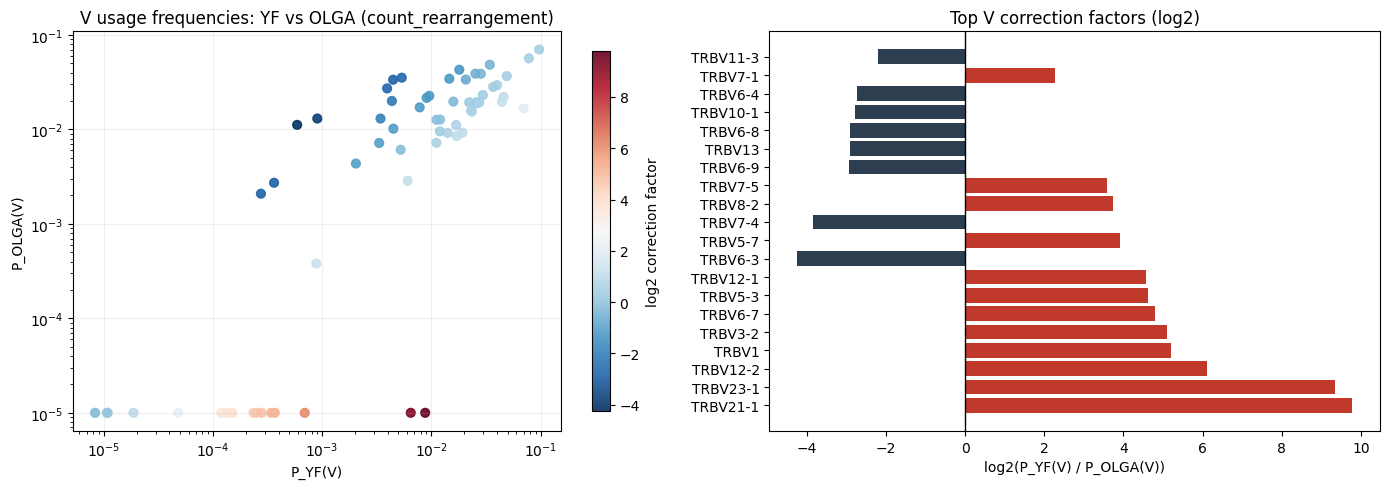

In [ ]:
olga_model = OlgaModel(locus="TRB", seed=SEED)
olga_gu = olga_model.compute_usage_cache(n=OLGA_USAGE_N, seed=SEED)

# Centralized frequency + factor computation from GeneUsage module
v_cmp = yfv_gu.usage_comparison(
    olga_gu,
    "TRB",
    scope="v",
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)
vj_cmp = yfv_gu.usage_comparison(
    olga_gu,
    "TRB",
    scope="vj",
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)

v_df = pd.DataFrame(
    [
        {
            "v_gene": k,
            "p_yf": vals["p_self"],
            "p_olga": vals["p_reference"],
            "factor_v": vals["factor"],
        }
        for k, vals in v_cmp.items()
    ]
)
v_df["log2_factor_v"] = np.log2(np.clip(v_df["factor_v"].values, 1e-300, None))

vj_df = pd.DataFrame(
    [
        {
            "v_gene": k[0],
            "j_gene": k[1],
            "p_yf": vals["p_self"],
            "p_olga": vals["p_reference"],
            "factor_vj": vals["factor"],
        }
        for k, vals in vj_cmp.items()
    ]
)
vj_df["log2_factor_vj"] = np.log2(np.clip(vj_df["factor_vj"].values, 1e-300, None))

pgen_adj = PgenGeneUsageAdjustment(
    yfv_gu,
    cache_size=OLGA_USAGE_N,
    seed=SEED,
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
    reference=olga_gu,
)

print("Top V genes by |log2 factor|:")
display(v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(15))
print("Top VJ pairs by |log2 factor|:")
display(vj_df.assign(abs_log2=lambda d: d["log2_factor_vj"].abs()).sort_values("abs_log2", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.clip(v_df["p_yf"].values, 1e-12, None)
y = np.clip(v_df["p_olga"].values, 1e-12, None)
sc = axes[0].scatter(x, y, c=v_df["log2_factor_v"].values, cmap="RdBu_r", s=40, alpha=0.9)
axes[0].plot([x.min(), x.max()], [x.min(), x.max()], color="#666666", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("P_YF(V)")
axes[0].set_ylabel("P_OLGA(V)")
axes[0].set_title(f"V usage frequencies: YF vs OLGA ({USAGE_COUNT_MODE}, n={OLGA_USAGE_N:,})")
axes[0].grid(alpha=0.2)
cb = plt.colorbar(sc, ax=axes[0], shrink=0.9)
cb.set_label("log2 correction factor")

top = v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(20)
axes[1].barh(top["v_gene"], top["log2_factor_v"], color=["#c0392b" if z > 0 else "#2c3e50" for z in top["log2_factor_v"]])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Top V correction factors (log2)")
axes[1].set_xlabel("log2(P_YF(V) / P_OLGA(V))")

plt.tight_layout()
plt.show()

print(f"Zero-frequency OLGA V genes in comparison table: {(v_df['p_olga'] == 0).sum()}")

## 4. Build adjusted pool and compare LLW Pgen histogram to mock bins

Pool built: n_generated=200,000, bins=62, floor=-79, ceil=-18, elapsed=358.0s


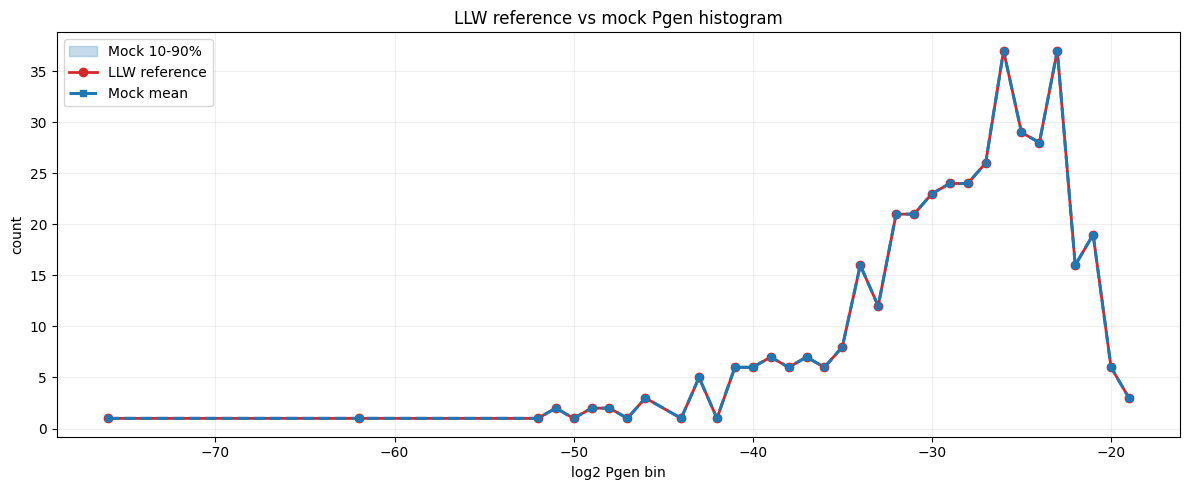

Mock vs LLW: median max|Delta p(bin)|=0.0000, p95=0.0000
Mock vs LLW: median RMSD=0.0000, p95=0.0000


In [5]:
t0 = pd.Timestamp.now()
pool = PgenBinPool(
    "TRB",
    n=POOL_SIZE,
    n_jobs=4,
    seed=SEED,
    pgen_adjustment=pgen_adj,
)
analysis = VDJBetOverlapAnalysis(
    vdjdb_rep,
    pool=pool,
    n_mocks=N_MOCKS,
    seed=SEED,
)
dt = (pd.Timestamp.now() - t0).total_seconds()
print(f"Pool built: n_generated={pool.n_generated:,}, bins={len(pool.bins)}, floor={pool.floor_bin}, ceil={pool.ceil_bin}, elapsed={dt:.1f}s")

ref_bins = analysis.get_reference_bin_sample()
mock_bins = analysis.get_mock_bin_samples()

ref_counts = Counter(ref_bins)
all_bins = sorted(ref_counts.keys())
if not all_bins:
    raise RuntimeError("No LLW reference bins available for diagnostics.")

mock_mat = []
for mb in mock_bins:
    mc = Counter(mb)
    mock_mat.append([mc.get(b, 0) for b in all_bins])
mock_mat = np.asarray(mock_mat, dtype=float)

ref_vec = np.array([ref_counts.get(b, 0) for b in all_bins], dtype=float)
mock_mean = mock_mat.mean(axis=0)
mock_q10 = np.quantile(mock_mat, 0.10, axis=0)
mock_q90 = np.quantile(mock_mat, 0.90, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(all_bins, mock_q10, mock_q90, alpha=0.25, color="#1f77b4", label="Mock 10-90%", zorder=1)
ax.plot(all_bins, ref_vec, color="#d62728", marker="o", linewidth=2, label="LLW reference", zorder=2)
# Draw mock mean last so it remains visible even when overlapping the reference line.
ax.plot(all_bins, mock_mean, color="#1f77b4", linestyle="--", marker="s", markersize=4, linewidth=2.2, label="Mock mean", zorder=3)
ax.set_xlabel("log2 Pgen bin")
ax.set_ylabel("count")
ax.set_title("LLW reference vs mock Pgen histogram")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

ref_prob = ref_vec / max(ref_vec.sum(), 1.0)
mock_probs = mock_mat / np.clip(mock_mat.sum(axis=1, keepdims=True), 1.0, None)
max_abs_diff = np.max(np.abs(mock_probs - ref_prob[None, :]), axis=1)
rmsd = np.sqrt(np.mean((mock_probs - ref_prob[None, :]) ** 2, axis=1))
print(f"Mock vs LLW: median max|Delta p(bin)|={np.median(max_abs_diff):.4f}, p95={np.percentile(max_abs_diff,95):.4f}")
print(f"Mock vs LLW: median RMSD={np.median(rmsd):.4f}, p95={np.percentile(rmsd,95):.4f}")

## 5. LLW overlap per sample: matched clonotypes and duplicate_count

Compute for each donor/day/replica:
- real LLW overlap
- mock distribution summary
- z-score and empirical p-value
- Cohen d
- FDR-adjusted p-values

In [6]:
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out

rows = []
for i, s in enumerate(samples, start=1):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        r = analysis.score(s["repertoire"], allow_1mm=False, match_v=True, match_j=True)

    mn = np.array(r.mock_n, dtype=float)
    mdc = np.array(r.mock_dc, dtype=float)
    mdc_log2 = np.log2(mdc + 1.0)
    real_dc_log2 = math.log2(r.dc + 1.0)

    mn_mean = float(np.mean(mn))
    mn_sd = float(np.std(mn, ddof=1)) if len(mn) > 1 else 0.0
    mdc_mean = float(np.mean(mdc_log2))
    mdc_sd = float(np.std(mdc_log2, ddof=1)) if len(mdc_log2) > 1 else 0.0

    z_n = (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0
    z_dc = (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0

    p_n_emp = (np.sum(mn >= r.n) + 1.0) / (len(mn) + 1.0)
    p_dc_emp = (np.sum(mdc_log2 >= real_dc_log2) + 1.0) / (len(mdc_log2) + 1.0)

    rows.append({
        "donor": s["donor"],
        "day": s["day"],
        "replica": s["replica"],
        "sample_label": f"{s['donor']} {s['replica']}",
        "n_total": r.n_total,
        "dc_total": r.dc_total,
        "matched_n_real": float(r.n),
        "matched_n_mock_mean": mn_mean,
        "matched_n_mock_sd": mn_sd,
        "matched_n_z": z_n,
        "matched_n_p_emp": p_n_emp,
        "matched_n_cohen_d": (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0,
        "matched_dc_real": float(r.dc),
        "matched_dc_log2_real": real_dc_log2,
        "matched_dc_log2_mock_mean": mdc_mean,
        "matched_dc_log2_mock_sd": mdc_sd,
        "matched_dc_log2_z": z_dc,
        "matched_dc_log2_p_emp": p_dc_emp,
        "matched_dc_log2_cohen_d": (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0,
        "mock_n": list(mn),
        "mock_dc_log2": list(mdc_log2),
    })

    if i % 10 == 0:
        print(f"Processed {i}/{len(samples)} samples")

df_res = pd.DataFrame(rows).sort_values(["donor", "replica", "day"]).reset_index(drop=True)
df_res["matched_n_p_adj"] = bh_fdr(df_res["matched_n_p_emp"].values)
df_res["matched_dc_log2_p_adj"] = bh_fdr(df_res["matched_dc_log2_p_emp"].values)

display(df_res[[
    "donor", "replica", "day",
    "matched_n_real", "matched_n_mock_mean", "matched_n_z", "matched_n_p_emp", "matched_n_cohen_d",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_cohen_d",
]])

Processed 10/42 samples
Processed 20/42 samples
Processed 30/42 samples
Processed 40/42 samples


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_z,matched_n_p_emp,matched_n_cohen_d,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_cohen_d
0,P1,F1,-1,11.0,8.435,0.908248,0.228856,0.908248,55.0,5.807355,3.992601,2.885898,0.004975,2.885898
1,P1,F1,0,13.0,7.420,2.069515,0.039801,2.069515,48.0,5.614710,3.665429,3.036430,0.004975,3.036430
2,P1,F1,7,21.0,9.840,3.724286,0.004975,3.724286,100.0,6.658211,4.382512,3.664284,0.004975,3.664284
3,P1,F1,15,28.0,10.510,5.578715,0.004975,5.578715,364.0,8.511753,4.611131,5.469135,0.004975,5.469135
4,P1,F1,45,18.0,7.475,3.907364,0.004975,3.907364,432.0,8.758223,3.762800,7.246855,0.004975,7.246855
5,P1,F2,0,11.0,7.290,1.487935,0.099502,1.487935,45.0,5.523562,3.556865,3.320942,0.004975,3.320942
6,P2,F1,-1,20.0,11.505,2.777158,0.009950,2.777158,61.0,5.954196,4.900775,1.470753,0.064677,1.470753
7,P2,F1,0,16.0,7.905,2.981257,0.009950,2.981257,41.0,5.392317,3.868474,2.225011,0.019900,2.225011
8,P2,F1,7,29.0,12.300,5.474223,0.004975,5.474223,88.0,6.475733,4.942631,2.271581,0.029851,2.271581
9,P2,F1,15,34.0,12.285,6.361491,0.004975,6.361491,278.0,8.124121,4.834431,5.620815,0.004975,5.620815


## 6. Lines (LLW real) and boxplots (mock)

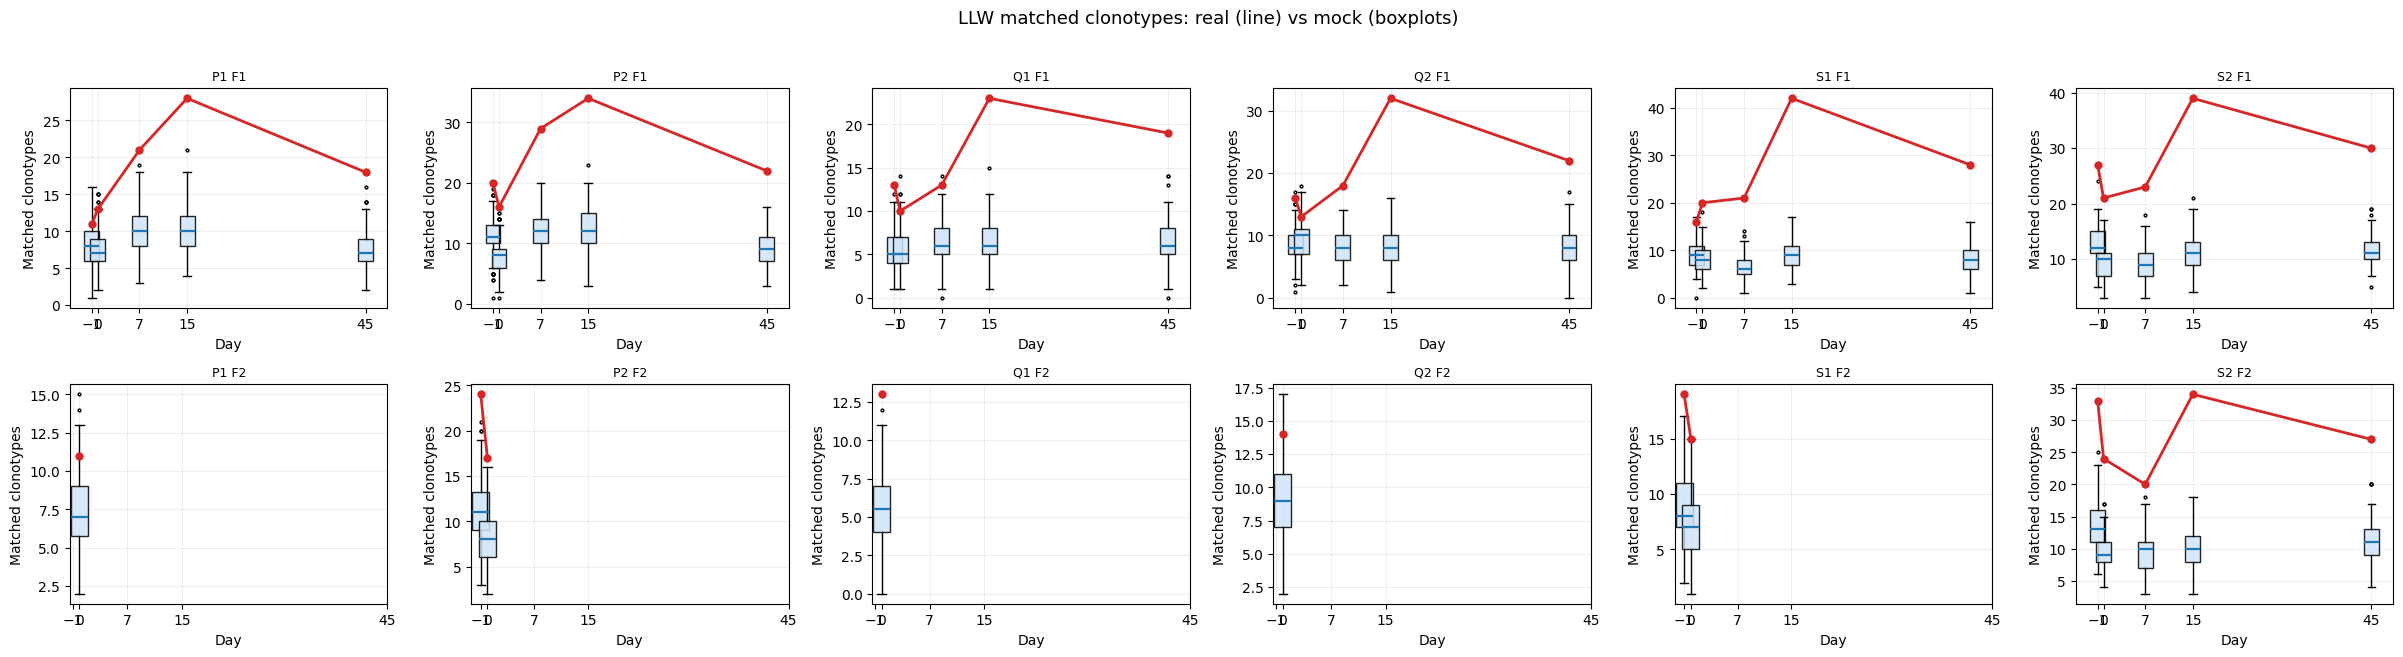

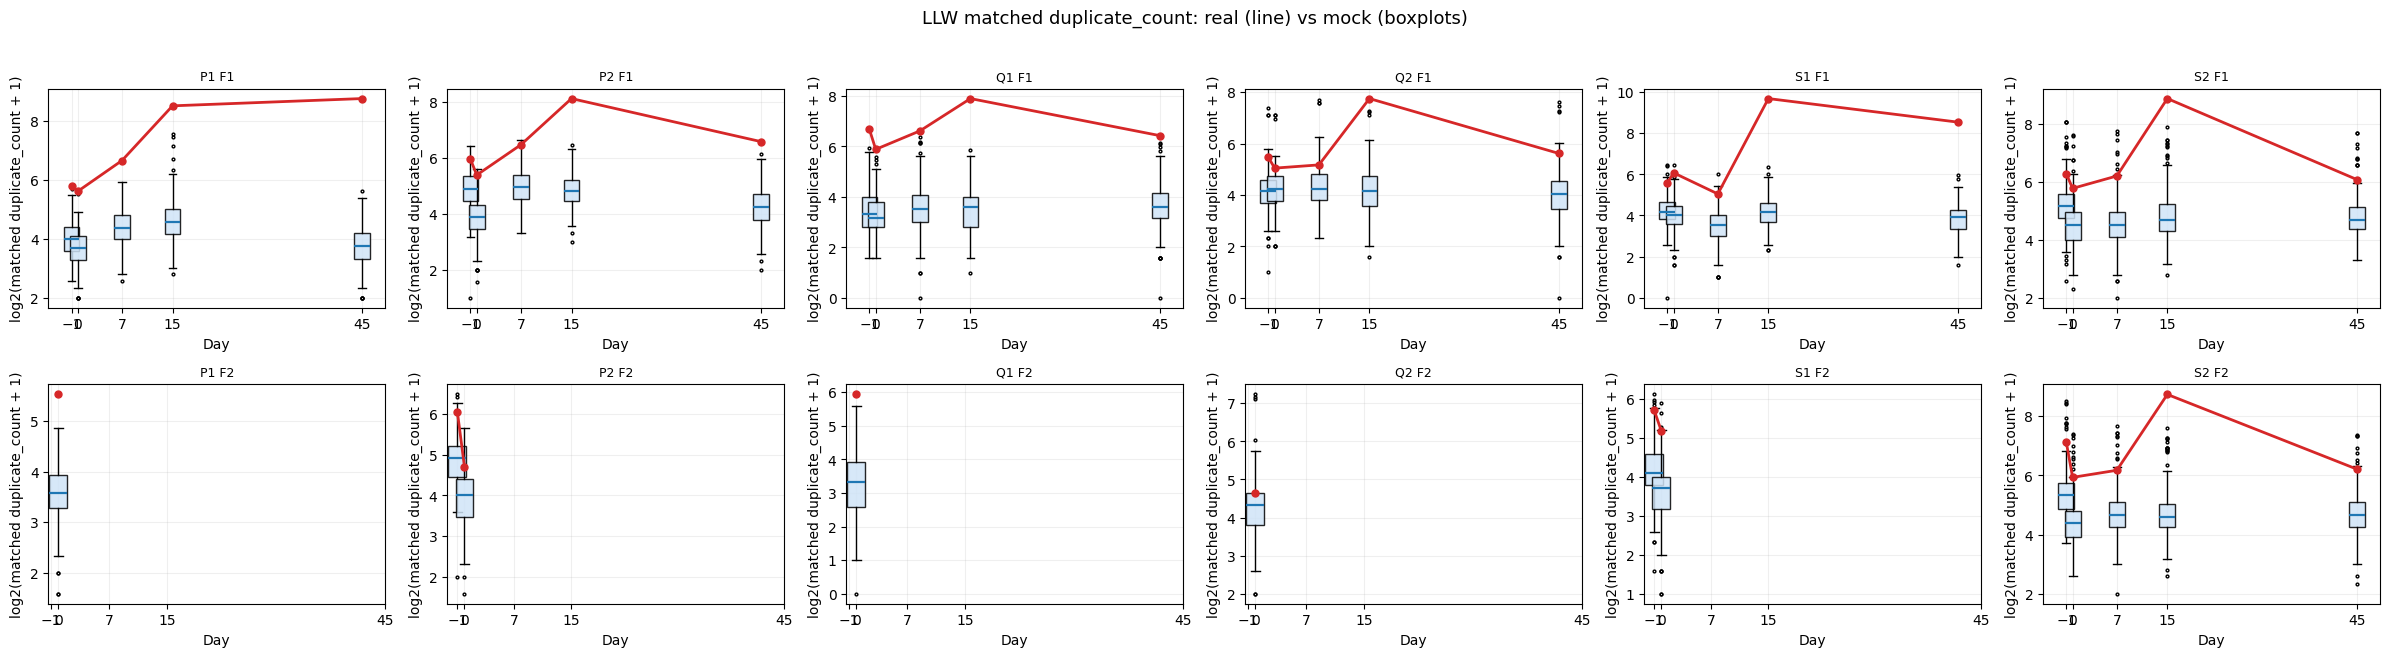

In [8]:
plot_rows = []
for _, r in df_res.iterrows():
    for x in r["mock_n"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_n", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_n", "kind": "real", "value": float(r["matched_n_real"]),
    })

    for x in r["mock_dc_log2"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_dc_log2", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_dc_log2", "kind": "real", "value": float(r["matched_dc_log2_real"]),
    })

plot_df = pd.DataFrame(plot_rows)
days_all = sorted(df_res["day"].unique().tolist())
donors = sorted(df_res["donor"].unique().tolist())
replicas = sorted(df_res["replica"].unique().tolist())

def draw_panel(metric, ylabel, title):
    fig, axes = plt.subplots(len(replicas), len(donors), figsize=(4.0 * len(donors), 3.2 * len(replicas)), squeeze=False)
    fig.suptitle(title, fontsize=13, y=1.02)
    for ri, rep in enumerate(replicas):
        for di, donor in enumerate(donors):
            ax = axes[ri, di]
            sub = plot_df[(plot_df["metric"] == metric) & (plot_df["donor"] == donor) & (plot_df["replica"] == rep)]
            if sub.empty:
                ax.set_visible(False)
                continue

            real = sub[sub["kind"] == "real"].sort_values("day")
            mock = sub[sub["kind"] == "mock"]
            box_data = [mock[mock["day"] == d]["value"].values for d in days_all]
            width = 2.5
            ax.boxplot(
                box_data,
                positions=days_all,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="#d0e4f7", alpha=0.85),
                medianprops=dict(color="#1f77b4", linewidth=1.6),
                flierprops=dict(markersize=2),
                manage_ticks=False,
            )
            ax.plot(real["day"], real["value"], "-o", color="#d62728", linewidth=2, markersize=5, zorder=5)
            ax.set_xticks(days_all)
            ax.set_xlabel("Day")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{donor} {rep}", fontsize=9)
            ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

draw_panel("matched_n", "Matched clonotypes", "LLW matched clonotypes: real (line) vs mock (boxplots)")
draw_panel("matched_dc_log2", "log2(matched duplicate_count + 1)", "LLW matched duplicate_count: real (line) vs mock (boxplots)")

## 7. Cohen d heatmaps

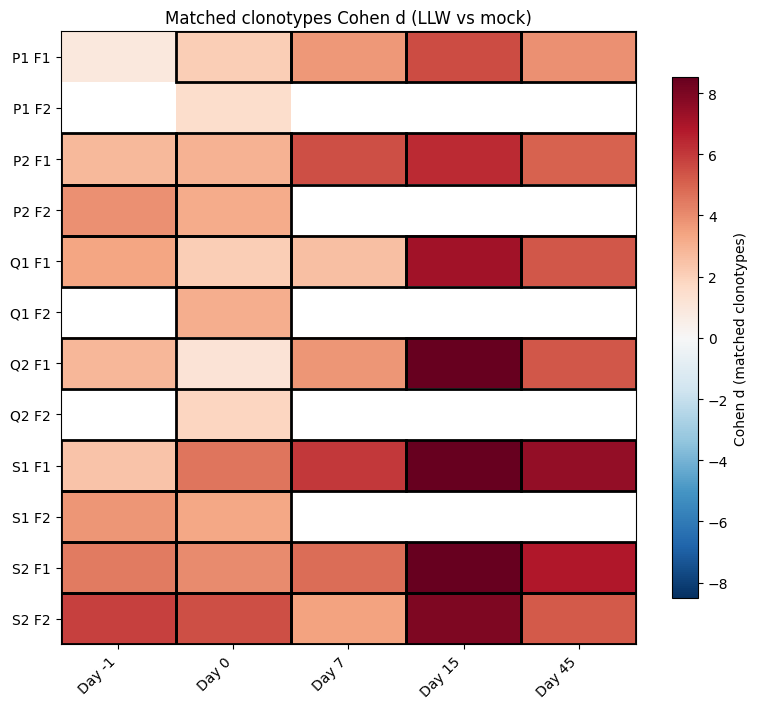

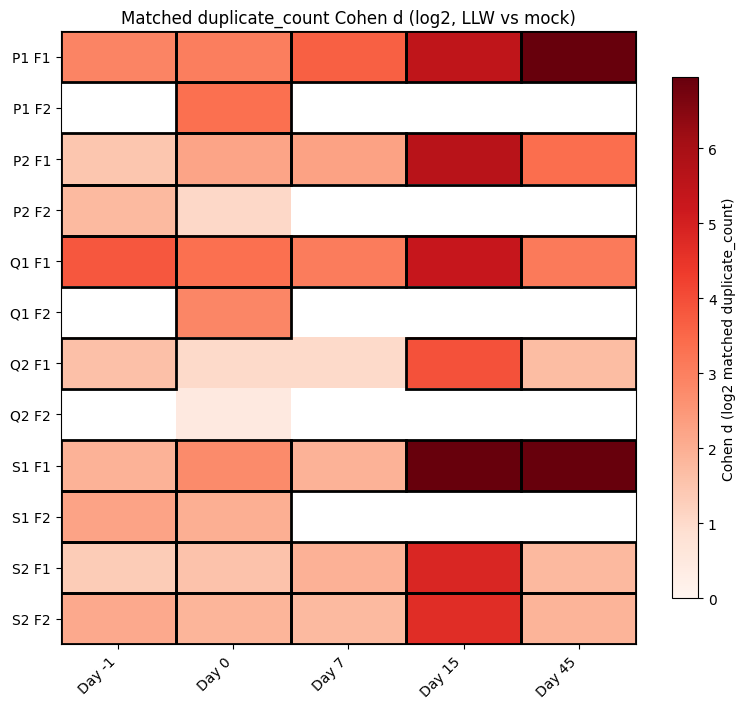

In [9]:
def heatmap_cohen(value_col, p_adj_col, title, cbar_label, cmap="RdBu_r", vlim=None):
    work = df_res.copy()
    work["sample"] = work["donor"] + " " + work["replica"]
    pv = work.pivot_table(index="sample", columns="day", values=value_col, aggfunc="first")
    pp = work.pivot_table(index="sample", columns="day", values=p_adj_col, aggfunc="first")

    mat = pv.values.astype(float)
    if vlim is None:
        vmax = max(1.0, np.nanpercentile(np.abs(mat), 95))
        vmin = -vmax
    else:
        vmin, vmax = vlim

    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.6 * pv.shape[0])))
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax, interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(cbar_label)

    for r in range(pv.shape[0]):
        for c in range(pv.shape[1]):
            p = pp.values[r, c]
            d = pv.values[r, c]
            if pd.notna(p) and pd.notna(d) and (float(p) < 0.10) and (float(d) > 0):
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([f"Day {d}" for d in pv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

heatmap_cohen(
    value_col="matched_n_cohen_d",
    p_adj_col="matched_n_p_adj",
    title="Matched clonotypes Cohen d (LLW vs mock)",
    cbar_label="Cohen d (matched clonotypes)",
    cmap="RdBu_r",
)

heatmap_cohen(
    value_col="matched_dc_log2_cohen_d",
    p_adj_col="matched_dc_log2_p_adj",
    title="Matched duplicate_count Cohen d (log2, LLW vs mock)",
    cbar_label="Cohen d (log2 matched duplicate_count)",
    cmap="Reds",
    vlim=(0, max(1.0, np.nanpercentile(df_res["matched_dc_log2_cohen_d"].values, 95))),
)

## 8. Final summary tables

In [10]:
summary_cols = [
    "donor", "replica", "day",
    "matched_n_real", "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z", "matched_n_p_emp", "matched_n_p_adj",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj",
]
summary = df_res[summary_cols].copy()
for col in [
    "matched_n_real", "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z",
]:
    summary[col] = summary[col].astype(float).round(3)
for col in ["matched_n_p_emp", "matched_n_p_adj", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

display(summary.sort_values(["donor", "replica", "day"]).reset_index(drop=True))

print("Top positive matched clonotype effects by Cohen d:")
display(summary.sort_values("matched_n_cohen_d", ascending=False).head(12))

print("Top positive matched duplicate_count effects by Cohen d:")
display(summary.sort_values("matched_dc_log2_cohen_d", ascending=False).head(12))

,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
0,P1,F1,-1,11.0,8.435,2.824,0.908,0.908,0.2289,0.2289,55.0,5.807,3.993,0.629,2.886,2.886,0.0050,0.0110
1,P1,F1,0,13.0,7.420,2.696,2.070,2.070,0.0398,0.0440,48.0,5.615,3.665,0.642,3.036,3.036,0.0050,0.0110
2,P1,F1,7,21.0,9.840,2.997,3.724,3.724,0.0050,0.0075,100.0,6.658,4.383,0.621,3.664,3.664,0.0050,0.0110
3,P1,F1,15,28.0,10.510,3.135,5.579,5.579,0.0050,0.0075,364.0,8.512,4.611,0.713,5.469,5.469,0.0050,0.0110
4,P1,F1,45,18.0,7.475,2.694,3.907,3.907,0.0050,0.0075,432.0,8.758,3.763,0.689,7.247,7.247,0.0050,0.0110
5,P1,F2,0,11.0,7.290,2.493,1.488,1.488,0.0995,0.1045,45.0,5.524,3.557,0.592,3.321,3.321,0.0050,0.0110
6,P2,F1,-1,20.0,11.505,3.059,2.777,2.777,0.0100,0.0123,61.0,5.954,4.901,0.716,1.471,1.471,0.0647,0.0715
7,P2,F1,0,16.0,7.905,2.715,2.981,2.981,0.0100,0.0123,41.0,5.392,3.868,0.685,2.225,2.225,0.0199,0.0398
8,P2,F1,7,29.0,12.300,3.051,5.474,5.474,0.0050,0.0075,88.0,6.476,4.943,0.675,2.272,2.272,0.0299,0.0522
9,P2,F1,15,34.0,12.285,3.414,6.361,6.361,0.0050,0.0075,278.0,8.124,4.834,0.585,5.621,5.621,0.0050,0.0110


Top positive matched clonotype effects by Cohen d:


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,42.0,9.285,2.843,11.506,11.506,0.0050,0.0075,814.0,9.671,4.184,0.682,8.046,8.046,0.0050,0.0110
35,S2,F1,15,39.0,10.985,3.087,9.074,9.074,0.0050,0.0075,471.0,8.883,4.843,0.832,4.855,4.855,0.0050,0.0110
22,Q2,F1,15,32.0,7.915,2.819,8.543,8.543,0.0050,0.0075,214.0,7.748,4.196,0.903,3.932,3.932,0.0050,0.0110
40,S2,F2,15,34.0,10.200,2.999,7.936,7.936,0.0050,0.0075,424.0,8.731,4.719,0.859,4.669,4.669,0.0050,0.0110
29,S1,F1,45,28.0,8.095,2.669,7.459,7.459,0.0050,0.0075,368.0,8.527,3.830,0.669,7.019,7.019,0.0050,0.0110
16,Q1,F1,15,23.0,6.290,2.346,7.123,7.123,0.0050,0.0075,237.0,7.895,3.480,0.834,5.296,5.296,0.0050,0.0110
36,S2,F1,45,30.0,11.615,2.708,6.789,6.789,0.0050,0.0075,67.0,6.087,4.819,0.711,1.785,1.785,0.0547,0.0657
9,P2,F1,15,34.0,12.285,3.414,6.361,6.361,0.0050,0.0075,278.0,8.124,4.834,0.585,5.621,5.621,0.0050,0.0110
27,S1,F1,7,21.0,6.335,2.448,5.991,5.991,0.0050,0.0075,32.0,5.044,3.454,0.835,1.906,1.906,0.0299,0.0522
37,S2,F2,-1,33.0,13.525,3.341,5.828,5.828,0.0050,0.0075,138.0,7.119,5.384,0.822,2.110,2.110,0.0498,0.0657


Top positive matched duplicate_count effects by Cohen d:


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,42.0,9.285,2.843,11.506,11.506,0.0050,0.0075,814.0,9.671,4.184,0.682,8.046,8.046,0.0050,0.0110
4,P1,F1,45,18.0,7.475,2.694,3.907,3.907,0.0050,0.0075,432.0,8.758,3.763,0.689,7.247,7.247,0.0050,0.0110
29,S1,F1,45,28.0,8.095,2.669,7.459,7.459,0.0050,0.0075,368.0,8.527,3.830,0.669,7.019,7.019,0.0050,0.0110
9,P2,F1,15,34.0,12.285,3.414,6.361,6.361,0.0050,0.0075,278.0,8.124,4.834,0.585,5.621,5.621,0.0050,0.0110
3,P1,F1,15,28.0,10.510,3.135,5.579,5.579,0.0050,0.0075,364.0,8.512,4.611,0.713,5.469,5.469,0.0050,0.0110
16,Q1,F1,15,23.0,6.290,2.346,7.123,7.123,0.0050,0.0075,237.0,7.895,3.480,0.834,5.296,5.296,0.0050,0.0110
35,S2,F1,15,39.0,10.985,3.087,9.074,9.074,0.0050,0.0075,471.0,8.883,4.843,0.832,4.855,4.855,0.0050,0.0110
40,S2,F2,15,34.0,10.200,2.999,7.936,7.936,0.0050,0.0075,424.0,8.731,4.719,0.859,4.669,4.669,0.0050,0.0110
22,Q2,F1,15,32.0,7.915,2.819,8.543,8.543,0.0050,0.0075,214.0,7.748,4.196,0.903,3.932,3.932,0.0050,0.0110
13,Q1,F1,-1,13.0,5.580,2.197,3.377,3.377,0.0050,0.0075,101.0,6.672,3.413,0.857,3.805,3.805,0.0050,0.0110


Notebook output coverage checklist:

- V usage YF vs OLGA and correction factors
- LLW reference vs mock Pgen histogram alignment
- Matched clonotypes and duplicate_count per sample
- Cohen d, z-scores, empirical p-values, FDR
- Line + boxplot dynamics and Cohen d heatmaps

In [11]:
print("Done: notebook rewritten to Rmd-aligned workflow.")
print(f"Samples: {len(samples)}, mocks: {N_MOCKS}, pool size: {POOL_SIZE:,}")
print("Use the summary table above for export/reporting.")

Done: notebook rewritten to Rmd-aligned workflow.
Samples: 42, mocks: 200, pool size: 200,000
Use the summary table above for export/reporting.
